# Análisis exploratorio de datos de partidos de fútbol

**Proyecto:** Predicción de resultados de partidos de fútbol  
**Integrantes:** Jorge Fabian Jove Aliaga y ____________________  
**Asignatura:** ____________________  

## Objetivo de negocio

Analizar el comportamiento de los resultados, los goles y el puntaje ELO para identificar patrones útiles en la futura construcción de un modelo que prediga si un partido termina en victoria local, empate o victoria visitante.


## 1. Importación de librerías

Se utilizan `pandas` para manipular los datos, `matplotlib` y `seaborn` para generar gráficos, y funciones estadísticas para cuantificar relaciones entre variables.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)


## 2. Carga, fuente y unidad de análisis

**Fuente:** archivo analítico `partidos_modelo.csv`, preparado por el equipo del proyecto con encuentros de la temporada 2025-2026. El archivo reúne resultados deportivos y puntajes ELO de los equipos.

**Unidad de análisis:** cada fila representa un partido de fútbol entre un equipo local y un equipo visitante.

**Variable objetivo:** `resultado`, codificada de la siguiente manera:

- `S`: victoria del equipo local.
- `H`: empate.
- `A`: victoria del equipo visitante.


## 3. Exploración inicial

Primero se revisan la cantidad de registros, el número de variables, sus nombres y sus tipos. Esto permite conocer la estructura general del conjunto de datos antes de analizarlo.


In [ ]:
print(f"Cantidad de registros: {datos.shape[0]}")
print(f"Cantidad de variables: {datos.shape[1]}")
print("\nVariables y tipos de datos:")
datos.info()


Cantidad de registros: 380
Cantidad de variables: 8

Variables y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             380 non-null    datetime64[ns]
 1   equipo_local      380 non-null    object        
 2   equipo_visitante  380 non-null    object        
 3   goles_local       380 non-null    int64         
 4   goles_visitante   380 non-null    int64         
 5   resultado         380 non-null    object        
 6   elo_local         380 non-null    int64         
 7   elo_visitante     380 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 23.9+ KB


**Interpretación:** el conjunto contiene 380 partidos y 8 variables. Las variables incluyen la fecha, los nombres de los equipos, los goles, el resultado y los puntajes ELO. Después de la conversión, `fecha` tiene un tipo temporal adecuado para futuros análisis cronológicos.


In [ ]:
datos.describe(include="all")


,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,resultado,elo_local,elo_visitante
count,380,380,380,380.000000,380.000000,380,380.000000,380.000000
unique,NaN,20,20,NaN,NaN,3,NaN,NaN
top,NaN,Girona,Vallecano,NaN,NaN,S,NaN,NaN
freq,NaN,19,19,NaN,NaN,186,NaN,NaN
mean,2026-01-08 20:58:06.315789568,NaN,NaN,1.573684,1.121053,NaN,1498.255263,1501.573684
min,2025-08-15 00:00:00,NaN,NaN,0.000000,0.000000,NaN,1391.000000,1387.000000
25%,2025-10-25 18:00:00,NaN,NaN,1.000000,0.000000,NaN,1457.000000,1459.000000
50%,2026-01-16 12:00:00,NaN,NaN,1.000000,1.000000,NaN,1484.500000,1490.500000
75%,2026-03-21 00:00:00,NaN,NaN,2.000000,2.000000,NaN,1523.000000,1529.250000
max,2026-05-24 00:00:00,NaN,NaN,6.000000,5.000000,NaN,1728.000000,1740.000000


## 4. Métrica principal

Para este análisis exploratorio se utiliza como métrica principal la **tasa de victoria local**, es decir, el porcentaje de partidos ganados por el equipo que juega como local. Esta métrica es relevante porque permite medir la presencia de una posible ventaja de localía.


In [ ]:
cantidad_partidos = len(datos)
victorias_locales = (datos["resultado"] == "S").sum()
tasa_victoria_local = victorias_locales / cantidad_partidos * 100

print(f"Partidos analizados: {cantidad_partidos}")
print(f"Victorias locales: {victorias_locales}")
print(f"Tasa de victoria local: {tasa_victoria_local:.2f}%")


Partidos analizados: 380
Victorias locales: 186
Tasa de victoria local: 48.95%


**Interpretación:** el equipo local gana aproximadamente el 48,95 % de los encuentros. Esto muestra una ventaja de localía importante, aunque no significa que la condición de local determine por sí sola el resultado.


# Respuestas a las cinco preguntas del EDA

## Pregunta 1. ¿Cuántos registros y variables existen?

Se comprueba nuevamente el tamaño y se muestran los nombres de todas las variables.


In [ ]:
print(f"El dataset contiene {datos.shape[0]} registros y {datos.shape[1]} variables.")
print("Variables:", list(datos.columns))


El dataset contiene 380 registros y 8 variables.
Variables: ['fecha', 'equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'resultado', 'elo_local', 'elo_visitante']


**Respuesta:** existen 380 registros y 8 variables. Cada registro corresponde a un partido.

## Pregunta 2. ¿Existen datos faltantes?

Se contabilizan los valores nulos en cada variable.


In [ ]:
faltantes = datos.isnull().sum().to_frame("Cantidad de faltantes")
faltantes["Porcentaje"] = (faltantes["Cantidad de faltantes"] / len(datos) * 100).round(2)
faltantes


,Cantidad de faltantes,Porcentaje
fecha,0,0.0
equipo_local,0,0.0
equipo_visitante,0,0.0
goles_local,0,0.0
goles_visitante,0,0.0
resultado,0,0.0
elo_local,0,0.0
elo_visitante,0,0.0


**Respuesta:** no existen datos faltantes en ninguna variable. Por lo tanto, no fue necesario eliminar registros ni aplicar métodos de imputación.

## Pregunta 3. ¿Existen duplicados, inconsistencias o valores atípicos?

Se revisan filas duplicadas, valores inválidos y valores atípicos mediante el método del rango intercuartílico (IQR). Un valor es marcado como atípico si está por debajo de $Q_1-1.5(IQR)$ o por encima de $Q_3+1.5(IQR)$.


In [ ]:
duplicados = datos.duplicated().sum()
resultados_validos = {"S", "H", "A"}
resultados_invalidos = (~datos["resultado"].isin(resultados_validos)).sum()
goles_negativos = ((datos["goles_local"] < 0) | (datos["goles_visitante"] < 0)).sum()
equipos_iguales = (datos["equipo_local"] == datos["equipo_visitante"]).sum()

print(f"Filas duplicadas: {duplicados}")
print(f"Resultados con códigos inválidos: {resultados_invalidos}")
print(f"Partidos con goles negativos: {goles_negativos}")
print(f"Partidos con el mismo equipo como local y visitante: {equipos_iguales}")


Filas duplicadas: 0
Resultados con códigos inválidos: 0
Partidos con goles negativos: 0
Partidos con el mismo equipo como local y visitante: 0


In [ ]:
variables_numericas = ["goles_local", "goles_visitante", "elo_local", "elo_visitante"]
resumen_atipicos = []

for variable in variables_numericas:
    q1 = datos[variable].quantile(0.25)
    q3 = datos[variable].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    cantidad = ((datos[variable] < limite_inferior) | (datos[variable] > limite_superior)).sum()
    resumen_atipicos.append([variable, limite_inferior, limite_superior, cantidad])

pd.DataFrame(
    resumen_atipicos,
    columns=["Variable", "Límite inferior", "Límite superior", "Cantidad de atípicos"]
)


,Variable,Límite inferior,Límite superior,Cantidad de atípicos
0,goles_local,-0.500,3.500,25
1,goles_visitante,-3.000,5.000,0
2,elo_local,1358.000,1622.000,21
3,elo_visitante,1353.625,1634.625,16


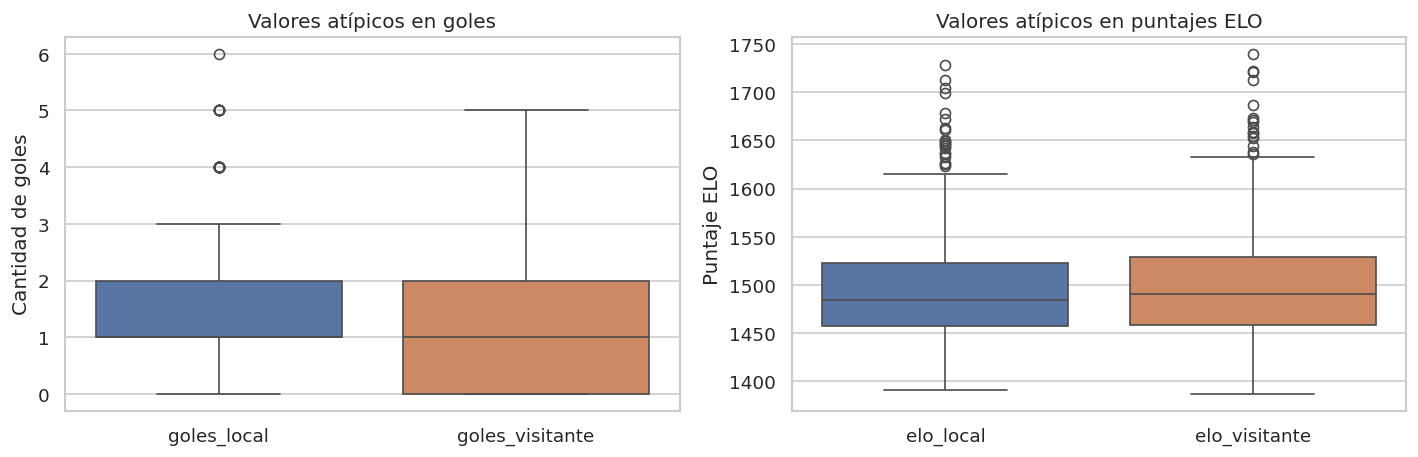

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=datos[["goles_local", "goles_visitante"]], ax=ejes[0])
ejes[0].set_title("Valores atípicos en goles")
ejes[0].set_ylabel("Cantidad de goles")

sns.boxplot(data=datos[["elo_local", "elo_visitante"]], ax=ejes[1])
ejes[1].set_title("Valores atípicos en puntajes ELO")
ejes[1].set_ylabel("Puntaje ELO")

plt.tight_layout()
plt.show()


**Respuesta:** no se encontraron duplicados ni inconsistencias básicas. El método IQR identifica algunos resultados extremos, especialmente partidos con muchos goles y equipos con ELO elevado. Estos casos no se eliminan porque son valores posibles y aportan información deportiva relevante.

## Pregunta 4. ¿Cómo se distribuyen los datos?

Para la variable categórica `resultado` se utiliza un gráfico de barras. Para los goles, que son variables numéricas discretas, se utilizan histogramas.


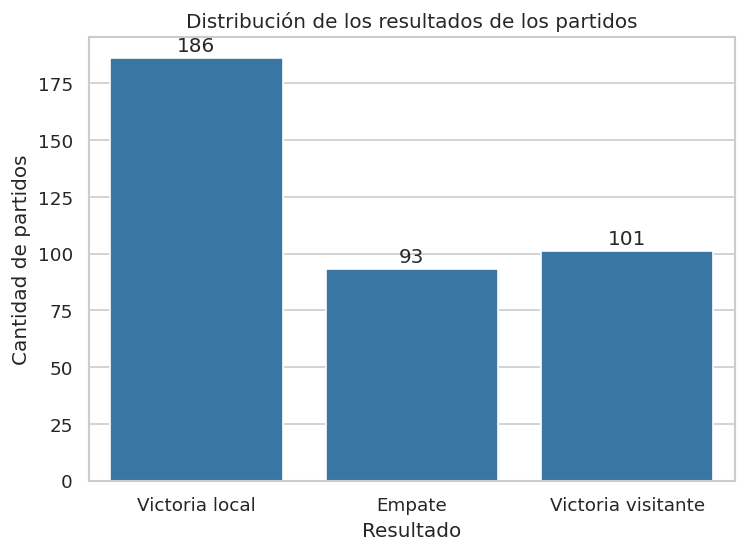

,Cantidad,Porcentaje
resultado,,
Victoria local,186,48.95
Empate,93,24.47
Victoria visitante,101,26.58


In [ ]:
etiquetas = {"S": "Victoria local", "H": "Empate", "A": "Victoria visitante"}
orden = ["S", "H", "A"]
conteos = datos["resultado"].value_counts().reindex(orden)

ax = sns.barplot(x=[etiquetas[x] for x in orden], y=conteos.values, color="#2878B5")
ax.set_title("Distribución de los resultados de los partidos")
ax.set_xlabel("Resultado")
ax.set_ylabel("Cantidad de partidos")

for i, valor in enumerate(conteos.values):
    ax.text(i, valor + 3, str(valor), ha="center")

plt.tight_layout()
plt.show()

porcentajes = (conteos / len(datos) * 100).round(2)
pd.DataFrame({"Cantidad": conteos, "Porcentaje": porcentajes}).rename(index=etiquetas)


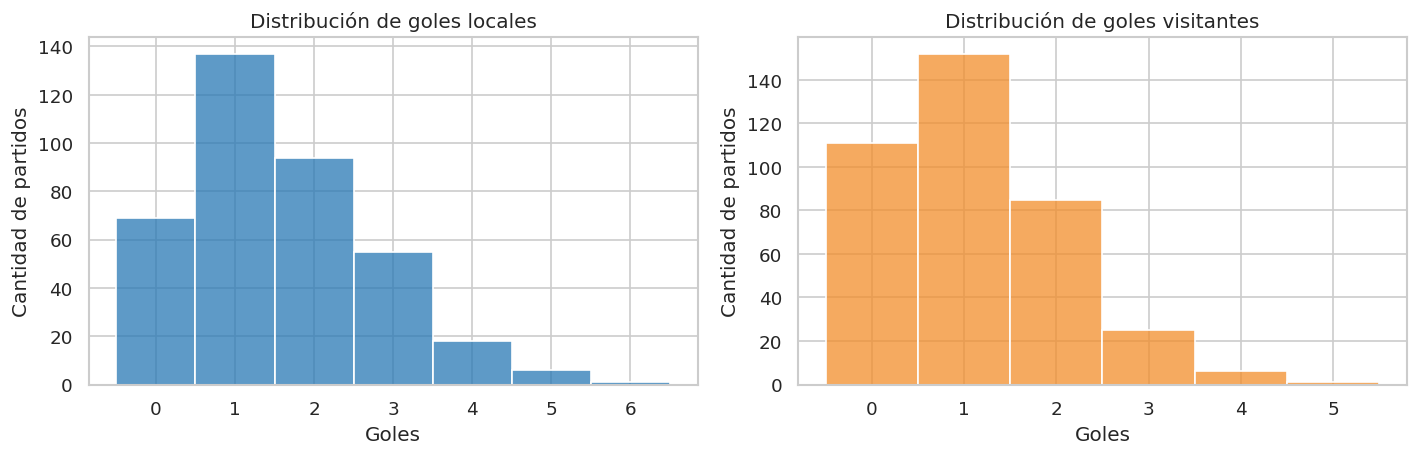

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(datos["goles_local"], discrete=True, ax=ejes[0], color="#2878B5")
ejes[0].set_title("Distribución de goles locales")
ejes[0].set_xlabel("Goles")
ejes[0].set_ylabel("Cantidad de partidos")

sns.histplot(datos["goles_visitante"], discrete=True, ax=ejes[1], color="#F28E2B")
ejes[1].set_title("Distribución de goles visitantes")
ejes[1].set_xlabel("Goles")
ejes[1].set_ylabel("Cantidad de partidos")

plt.tight_layout()
plt.show()


**Respuesta:** las victorias locales son el resultado más frecuente con 186 partidos (48,95 %), seguidas por 101 victorias visitantes (26,58 %) y 93 empates (24,47 %). La mayoría de los equipos marca entre 0 y 2 goles, mientras que los marcadores muy altos aparecen con menor frecuencia.

## Pregunta 5. ¿Qué relaciones existen entre las variables?

Se combinan gráficos de dispersión y una matriz de correlación. Los colores representan el resultado final del partido.


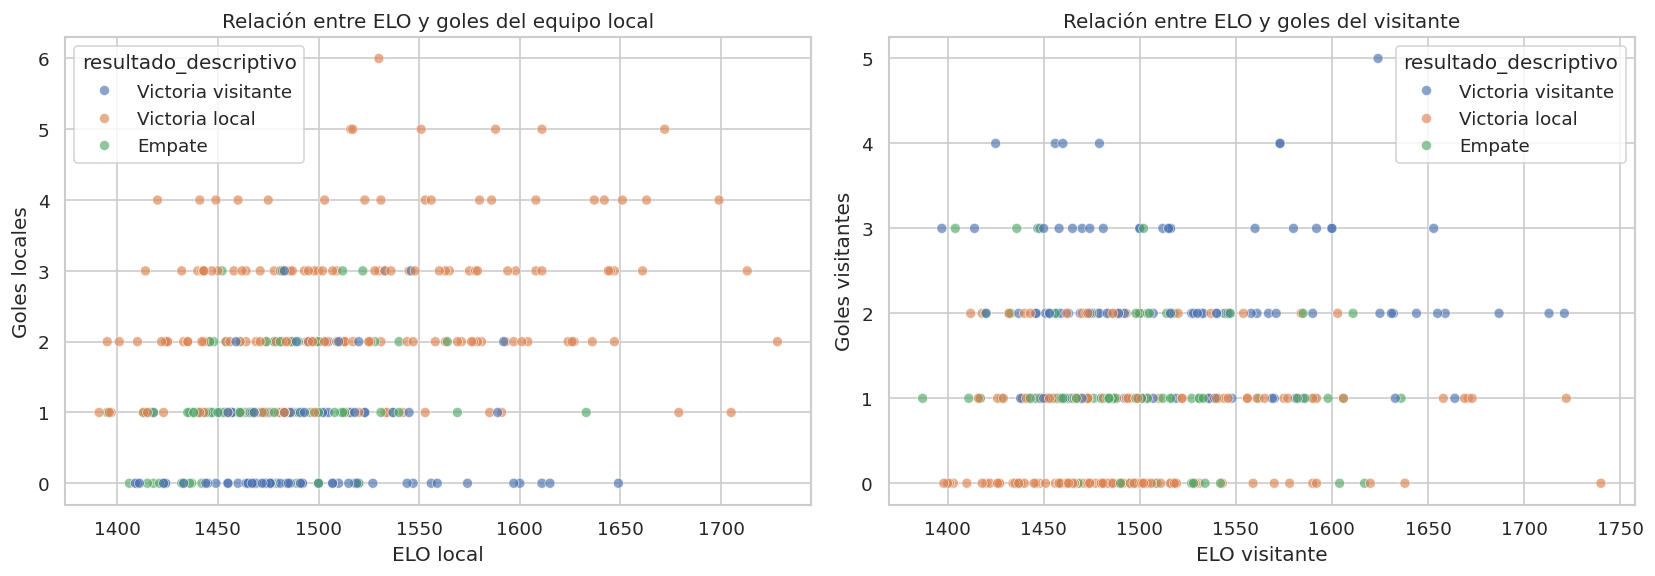

In [ ]:
datos_grafico = datos.assign(
    resultado_descriptivo=datos["resultado"].map(etiquetas)
)

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=datos_grafico,
    x="elo_local",
    y="goles_local",
    hue="resultado_descriptivo",
    alpha=0.65,
    ax=ejes[0]
)
ejes[0].set_title("Relación entre ELO y goles del equipo local")
ejes[0].set_xlabel("ELO local")
ejes[0].set_ylabel("Goles locales")

sns.scatterplot(
    data=datos_grafico,
    x="elo_visitante",
    y="goles_visitante",
    hue="resultado_descriptivo",
    alpha=0.65,
    ax=ejes[1]
)
ejes[1].set_title("Relación entre ELO y goles del visitante")
ejes[1].set_xlabel("ELO visitante")
ejes[1].set_ylabel("Goles visitantes")

plt.tight_layout()
plt.show()


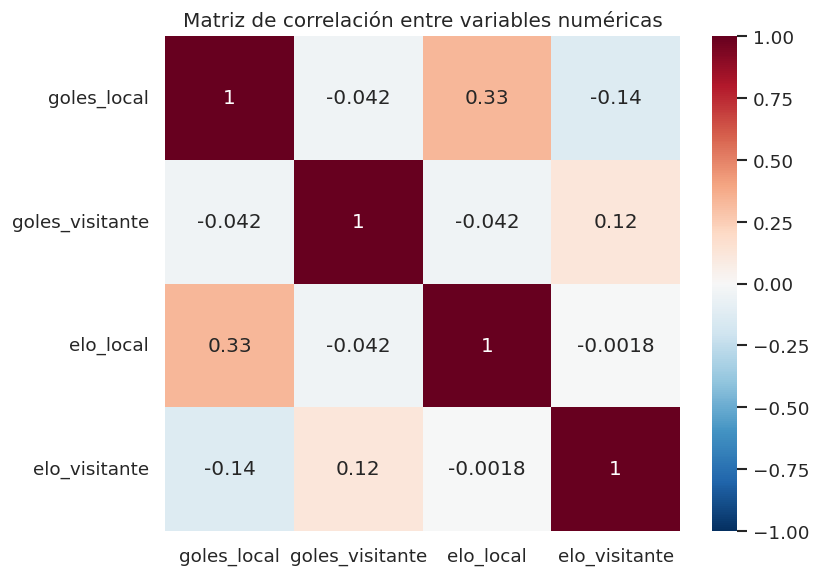

,goles_local,goles_visitante,elo_local,elo_visitante
goles_local,1.000,-0.042,0.329,-0.140
goles_visitante,-0.042,1.000,-0.042,0.122
elo_local,0.329,-0.042,1.000,-0.002
elo_visitante,-0.140,0.122,-0.002,1.000


In [ ]:
correlaciones = datos[variables_numericas].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlaciones, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

correlaciones.round(3)


**Respuesta:** la relación más visible es positiva y moderada entre el ELO local y los goles locales ($r pprox 0.329$). En cambio, la relación entre ELO visitante y goles visitantes es positiva pero débil ($r pprox 0.122$). Existe bastante superposición entre los resultados, por lo que el ELO aporta información, pero no explica por sí solo la cantidad de goles ni determina completamente el resultado.


## 6. Hallazgo interesante: ventaja del equipo local

El principal hallazgo consiste en comprobar si el equipo local obtiene mejores resultados y marca más goles que el visitante.


In [ ]:
promedio_local = datos["goles_local"].mean()
promedio_visitante = datos["goles_visitante"].mean()
diferencia = promedio_local - promedio_visitante

resumen_hallazgo = pd.DataFrame({
    "Indicador": [
        "Promedio de goles locales",
        "Promedio de goles visitantes",
        "Diferencia promedio",
        "Tasa de victoria local"
    ],
    "Valor": [
        round(promedio_local, 3),
        round(promedio_visitante, 3),
        round(diferencia, 3),
        f"{tasa_victoria_local:.2f}%"
    ]
})
resumen_hallazgo


,Indicador,Valor
0,Promedio de goles locales,1.574
1,Promedio de goles visitantes,1.121
2,Diferencia promedio,0.453
3,Tasa de victoria local,48.95%


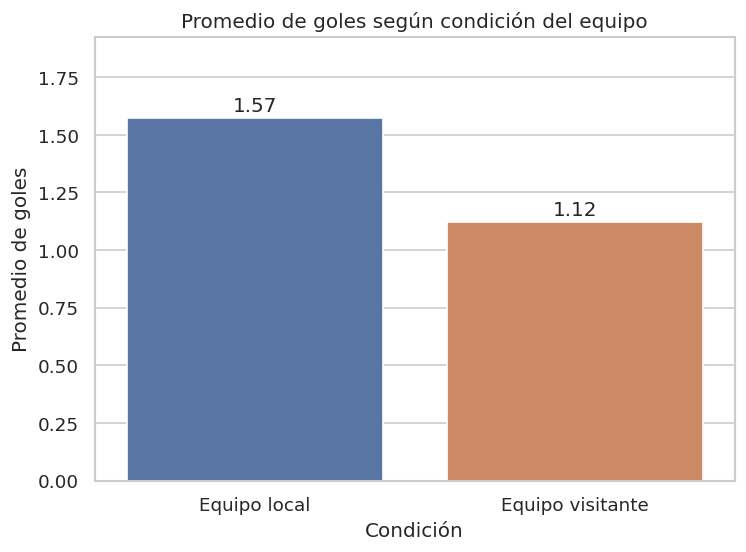

In [ ]:
promedios = pd.Series(
    [promedio_local, promedio_visitante],
    index=["Equipo local", "Equipo visitante"]
)

ax = sns.barplot(x=promedios.index, y=promedios.values, hue=promedios.index, legend=False)
ax.set_title("Promedio de goles según condición del equipo")
ax.set_xlabel("Condición")
ax.set_ylabel("Promedio de goles")

for i, valor in enumerate(promedios.values):
    ax.text(i, valor + 0.03, f"{valor:.2f}", ha="center")

plt.ylim(0, max(promedios.values) + 0.35)
plt.tight_layout()
plt.show()


**Interpretación del hallazgo:** los equipos locales anotan en promedio 1,57 goles por partido, mientras que los visitantes anotan 1,12. La diferencia es de aproximadamente 0,45 goles y coincide con una tasa de victoria local de 48,95 %. Esta evidencia sugiere una ventaja de localía que debería incluirse como factor en el futuro modelo predictivo.

## 7. Conclusiones

1. El conjunto analizado contiene 380 partidos y 8 variables, sin datos faltantes ni filas duplicadas.
2. Las victorias locales representan el resultado más frecuente, con el 48,95 % de los partidos.
3. La mayoría de los marcadores se concentra entre 0 y 2 goles por equipo.
4. El ELO local presenta una relación positiva moderada con los goles locales, pero las relaciones observadas no son lo suficientemente fuertes para explicar por sí solas los resultados.
5. La diferencia entre los promedios de goles locales y visitantes aporta evidencia de una ventaja de localía.
6. Para construir un modelo más completo se recomienda incorporar variables adicionales, como la forma reciente, lesiones, rendimiento ofensivo y defensivo, enfrentamientos previos y disponibilidad de jugadores.

> **Nota:** la métrica calculada en este notebook es descriptiva. Cuando se entrene y evalúe el modelo predictivo, deberán añadirse métricas como exactitud, precisión, exhaustividad y matriz de confusión sobre datos de prueba.
